In [88]:
import random
import os 

C_base_quality="/root/sunxh/data/IVT_normalC.signal.tsv"
C_read_dict={}
with open(C_base_quality) as f:
    count=0
    for line in f:
        items=line.split("\t")
        id=items[0]
        contig=items[1]
        start=int(items[2])
        seq=items[3]
        #contig_full_length=int(contig.split("_")[1])
        contig_full_length=1358-38
        
        if start<38+20 and len(seq)+20>contig_full_length and "C1" in contig:
            C_read_dict[id]=1
            count+=1
print("normalC read count:",count)
m5C_base_quality="/root/sunxh/data/IVT_m5C.signal.tsv"
m5C_read_dict={}
with open(m5C_base_quality) as f:
    count=0
    for line in f:
        items=line.split("\t")
        id=items[0]
        contig=items[1]
        start=int(items[2])
        seq=items[3]
        #contig_full_length=int( contig.split("_")[1])
        contig_full_length=1358-38
        if start<38+20 and len(seq)+20>contig_full_length and "C1" in contig:
            m5C_read_dict[id]=1
            count+=1
print("m5C read count:",count)


normalC read count: 30113
m5C read count: 24609


In [ ]:
import os
root_dir = "/root/sunxh/data/IVT_m5C_guppy_single/"
output_file = "/root/sunxh/data/m5c_c1_read.txt"
file_paths = []
for foldername, subfolders, filenames in os.walk(root_dir):
    for filename in filenames:
        if "filename_mapping" in filename:
            continue
        file_path = os.path.join(foldername,filename)
        file_paths.append(file_path)
with open(output_file, "w") as f:
    f.write("\n".join(file_paths))



In [ ]:
import random
# generate different mod rate dataset
mod_files="/root/sunxh/data/m5c_c1_read.txt"
unmod_files="/root/sunxh/data/normalc_c1_read.txt"
destination_folders=["/root/sunxh/data/m5C/data_stoichiometry1/mod_0",
                    "/root/sunxh/data/m5C/data_stoichiometry1/mod_20",
                    "/root/sunxh/data/m5C/data_stoichiometry1/mod_40",
                    "/root/sunxh/data/m5C/data_stoichiometry1/mod_60",
                    "/root/sunxh/data/m5C/data_stoichiometry1/mod_80",
                    "/root/sunxh/data/m5C/data_stoichiometry1/mod_100"]
for folder in destination_folders:
    os.makedirs(folder, exist_ok=True)
with open(mod_files) as f:
    count=0
    for i,line in enumerate(f):
        read_id=line.split("/")[-1].split(".")[0]
        if read_id not in m5C_read_dict:
            continue
        count+=1
        if count>2000:
            break
        if random.random()<0:
            cmd="cp %s %s" %(line.rstrip(),destination_folders[0])
            os.system(cmd)
        if random.random()<0.2:
            cmd="cp %s %s" %(line.rstrip(),destination_folders[1])
            os.system(cmd)
        if random.random()<0.4:
            cmd="cp %s %s" %(line.rstrip(),destination_folders[2])
            os.system(cmd)
        if random.random()<0.6:
            cmd="cp %s %s" %(line.rstrip(),destination_folders[3])
            os.system(cmd)
        if random.random()<0.8:
            cmd="cp %s %s" %(line.rstrip(),destination_folders[4])
            os.system(cmd)
        if random.random()<1:
            cmd="cp %s %s" %(line.rstrip(),destination_folders[5])
            os.system(cmd)
with open(unmod_files) as f:
    count=0
    for i,line in enumerate(f):
        read_id=line.split("/")[-1].split(".")[0]
        if read_id not in C_read_dict:
            continue
        count+=1
        if count>2000:
            break
        if random.random()>0:
            cmd="cp %s %s" %(line.rstrip(),destination_folders[0])
            os.system(cmd)
        if random.random()>0.2:
            cmd="cp %s %s" %(line.rstrip(),destination_folders[1])
            os.system(cmd)
        if random.random()>0.4:
            cmd="cp %s %s" %(line.rstrip(),destination_folders[2])
            os.system(cmd)
        if random.random()>0.6:
            cmd="cp %s %s" %(line.rstrip(),destination_folders[3])
            os.system(cmd)
        if random.random()>0.8:
            cmd="cp %s %s" %(line.rstrip(),destination_folders[4])
            os.system(cmd)
        if random.random()>1:
            cmd="cp %s %s" %(line.rstrip(),destination_folders[5])
            os.system(cmd)

In [12]:
#generate modification free sample 生成无修饰对照样本
unmod_files="/root/sunxh/data/normalc_c1_read.txt"
with open(unmod_files) as f:
    count=0
    for i,line in enumerate(f):
        read_id=line.split("/")[-1].split(".")[0]
        if read_id not in C_read_dict:
            continue
        count+=1
        if count<2000:
            continue
        if count>4000:
            break

        cmd="cp %s %s" %(line.rstrip(),"/root/sunxh/data/m5C/data_stoichiometry1/CK")
        os.system(cmd)

In [ ]:
tombo detect_modifications alternative_model --fast5-basedirs /root/sunxh/data/m5C/data_stoichiometry1/mod_0 \
    --statistics-file-basename /root/sunxh/data/m5C/data_stoichiometry1/mod_0 \
    --alternate-bases 5mC --processes 36
tombo detect_modifications alternative_model --fast5-basedirs /root/sunxh/data/m5C/data_stoichiometry1/mod_20 \
    --statistics-file-basename /root/sunxh/data/m5C/data_stoichiometry1/mod_20 \
    --alternate-bases 5mC --processes 36
tombo detect_modifications alternative_model --fast5-basedirs /root/sunxh/data/m5C/data_stoichiometry1/mod_40 \
    --statistics-file-basename /root/sunxh/data/m5C/data_stoichiometry1/mod_40 \
    --alternate-bases 5mC --processes 36
tombo detect_modifications alternative_model --fast5-basedirs /root/sunxh/data/m5C/data_stoichiometry1/mod_60 \
    --statistics-file-basename /root/sunxh/data/m5C/data_stoichiometry1/mod_60 \
    --alternate-bases 5mC --processes 36
tombo detect_modifications alternative_model --fast5-basedirs /root/sunxh/data/m5C/data_stoichiometry1/mod_80 \
    --statistics-file-basename /root/sunxh/data/m5C/data_stoichiometry1/mod_80 \
    --alternate-bases 5mC --processes 36
tombo detect_modifications alternative_model --fast5-basedirs /root/sunxh/data/m5C/data_stoichiometry1/mod_100 \
    --statistics-file-basename /root/sunxh/data/m5C/data_stoichiometry1/mod_100 \
    --alternate-bases 5mC --processes 36
#bash code
# produce wig file with estimated fraction of modified reads at each valid reference site

tombo text_output browser_files --statistics-filename /root/sunxh/data/m5C/data_stoichiometry1/mod_0.5mC.tombo.stats \
    --file-types dampened_fraction --browser-file-basename mod_0
tombo text_output browser_files --statistics-filename /root/sunxh/data/m5C/data_stoichiometry1/mod_20.5mC.tombo.stats \
    --file-types dampened_fraction --browser-file-basename mod_20
tombo text_output browser_files --statistics-filename /root/sunxh/data/m5C/data_stoichiometry1/mod_40.5mC.tombo.stats \
    --file-types dampened_fraction --browser-file-basename mod_40
tombo text_-oput browser_files --statistics-filename /root/sunxh/data/m5C/data_stoichiometry1/mod_60.5mC.tombo.stats \
    --file-types dampened_fraction --browser-file-basename mod_60
tombo text_output browser_files --statistics-filename /root/sunxh/data/m5C/data_stoichiometry1/mod_80.5mC.tombo.stats \
    --file-types dampened_fraction --browser-file-basename mod_80
tombo text_output browser_files --statistics-filename /root/sunxh/data/m5C/data_stoichiometry1/mod_100.5mC.tombo.stats \
    --file-types dampened_fraction --browser-file-basename mod_100

<ggplot: (640 x 480)>


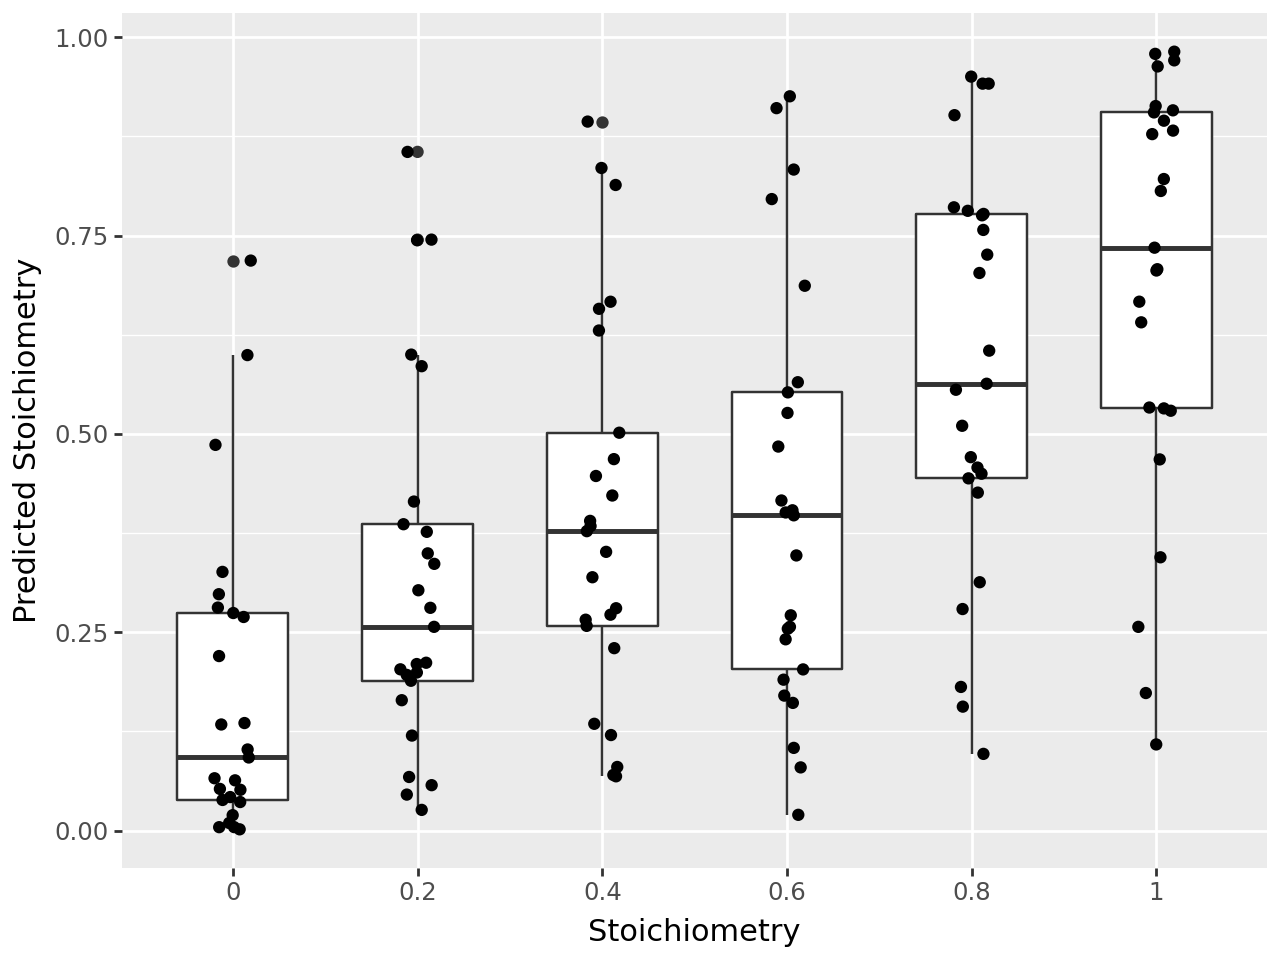

In [64]:
#tombo stoichiometry prediction plot

import pandas as pd
from plotnine import *

files=["/root/sunxh/data/mod_0.dampened_fraction_modified_reads.plus.wig",
       "/root/sunxh/data/mod_20.dampened_fraction_modified_reads.plus.wig",
       "/root/sunxh/data/mod_40.dampened_fraction_modified_reads.plus.wig",
       "/root/sunxh/data/mod_60.dampened_fraction_modified_reads.plus.wig",
       "/root/sunxh/data/mod_80.dampened_fraction_modified_reads.plus.wig",
       "/root/sunxh/data/mod_100.dampened_fraction_modified_reads.plus.wig"]

stoi_dict={0:"0",1:"0.2",2:"0.4",3:"0.6",4:"0.8",5:"1"}
X,Y,methods=[],[],[]
for i,file in enumerate(files):
    with open(file) as f:
        for j,line in enumerate(f):
            line=line.rstrip()
            if len(line.split(" "))==2 and j%10==0:
                mod_rate=float(line.split(" ")[1])
                X.append(stoi_dict[i])
                Y.append(mod_rate)
                methods.append("tombo")

data=pd.DataFrame({"Stoichiometry":X,"Predicted Stoichiometry":Y})
# 保存数据到 CSV 文件
data.to_csv("/root/sunxh/WaveCrossMamba/data_csv/tombo_stoichiometry_predictions.csv", index=False)

p=(ggplot(data, aes(x='Stoichiometry', y='Predicted Stoichiometry'))
    + geom_boxplot(width = 0.6)
    + geom_jitter(width = 0.1)
    + scale_x_discrete()
  )
print(p)
p.show()

In [ ]:
#guppy basecalling
guppy_basecaller -i /root/sunxh/data/m5C/data_stoichiometry1/mod_0 \
-s /root/sunxh/data/m5C/data_stoichiometry1/mod_0_guppy \
--num_callers 40 --recursive --fast5_out --config rna_r9.4.1_70bps_hac.cfg --device cuda:2&

guppy_basecaller -i /root/sunxh/data/m5C/data_stoichiometry1/mod_20 \
-s /root/sunxh/data/m5C/data_stoichiometry1/mod_20_guppy \
--num_callers 40 --recursive --fast5_out --config rna_r9.4.1_70bps_hac.cfg --device cuda:2&

guppy_basecaller -i /root/sunxh/data/m5C/data_stoichiometry1/mod_40 \
-s /root/sunxh/data/m5C/data_stoichiometry1/mod_40_guppy \
--num_callers 40 --recursive --fast5_out --config rna_r9.4.1_70bps_hac.cfg --device cuda:2&

guppy_basecaller -i /root/sunxh/data/m5C/data_stoichiometry1/mod_60 \
-s /root/sunxh/data/m5C/data_stoichiometry1/mod_60_guppy \
--num_callers 40 --recursive --fast5_out --config rna_r9.4.1_70bps_hac.cfg --device cuda:2&

guppy_basecaller -i /root/sunxh/data/m5C/data_stoichiometry1/mod_80 \
-s /root/sunxh/data/m5C/data_stoichiometry1/mod_80_guppy \
--num_callers 40 --recursive --fast5_out --config rna_r9.4.1_70bps_hac.cfg --device cuda:2&

guppy_basecaller -i /root/sunxh/data/m5C/data_stoichiometry1/mod_100 \
-s /root/sunxh/data/m5C/data_stoichiometry1/mod_100_guppy \
--num_callers 40 --recursive --fast5_out --config rna_r9.4.1_70bps_hac.cfg --device cuda:2&

guppy_basecaller -i /root/sunxh/data/m5C/data_stoichiometry1/CK \
-s /root/sunxh/data/m5C/data_stoichiometry1/CK_guppy \
--num_callers 40 --recursive --fast5_out --config rna_r9.4.1_70bps_hac.cfg --device cuda:2&


In [ ]:
#mapping
minimap2 -ax map-ont -uf -t 3 --secondary=no /root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/mod_0_guppy/pass/mod_0.fastq \
| samtools sort -o  /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_0.sorted.bam

minimap2 -ax map-ont -uf -t 3 --secondary=no /root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/mod_20_guppy/pass/mod_20.fastq \
| samtools sort -o  /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_20.sorted.bam

minimap2 -ax map-ont -uf -t 3  --secondary=no /root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/mod_40_guppy/pass/mod_40.fastq \
| samtools sort -o  /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_40.sorted.bam

minimap2 -ax map-ont -uf -t 3 --secondary=no /root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/mod_60_guppy/pass/mod_60.fastq \
| samtools sort -o  /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_60.sorted.bam

minimap2 -ax map-ont -uf -t 3 --secondary=no /root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/mod_80_guppy/pass/mod_80.fastq \
| samtools sort -o  /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_80.sorted.bam

minimap2 -ax map-ont -uf -t 3 --secondary=no /root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/mod_100_guppy/pass/mod_100.fastq \
| samtools sort -o  /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_100.sorted.bam

minimap2 -ax map-ont -uf -t 3 --secondary=no /root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/CK_guppy/pass/CK.fastq \
| samtools sort -o  /root/sunxh/data/m5C/data_stoichiometry1/xpore/CK.sorted.bam

In [10]:
from Bio import SeqIO

input_file = "/root/sunxh/data/fna/ELIGOS_reference.fa"
output_file = "/root/sunxh/data/fna/ELIGOS_C1.fa"

with open(output_file, "w") as out_f:
    for record in SeqIO.parse(input_file, "fasta"):
        if record.id == "C1":
            SeqIO.write(record, out_f, "fasta")
print(f"提取完成，C1 染色体已保存为 {output_file}")


提取完成，C1 染色体已保存为 /root/sunxh/data/fna/ELIGOS_C1.fa


In [ ]:
#naopolish index
nanopolish index -d /root/sunxh/data/m5C/data_stoichiometry1/mod_0 \
/root/sunxh/data/m5C/data_stoichiometry1/mod_0_guppy/pass/mod_0.fastq
nanopolish index -d /root/sunxh/data/m5C/data_stoichiometry1/mod_20 \
/root/sunxh/data/m5C/data_stoichiometry1/mod_20_guppy/pass/mod_20.fastq
nanopolish index -d /root/sunxh/data/m5C/data_stoichiometry1/mod_40 \
/root/sunxh/data/m5C/data_stoichiometry1/mod_40_guppy/pass/mod_40.fastq
nanopolish index -d /root/sunxh/data/m5C/data_stoichiometry1/mod_60 \
/root/sunxh/data/m5C/data_stoichiometry1/mod_60_guppy/pass/mod_60.fastq
nanopolish index -d /root/sunxh/data/m5C/data_stoichiometry1/mod_80 \
/root/sunxh/data/m5C/data_stoichiometry1/mod_80_guppy/pass/mod_80.fastq
nanopolish index -d /root/sunxh/data/m5C/data_stoichiometry1/mod_100 \
/root/sunxh/data/m5C/data_stoichiometry1/mod_100_guppy/pass/mod_100.fastq
nanopolish index -d /root/sunxh/data/m5C/data_stoichiometry1/CK \
/root/sunxh/data/m5C/data_stoichiometry1/CK_guppy/pass/CK.fastq

In [ ]:
#nanopolish eventalign 
nanopolish eventalign --reads /root/sunxh/data/m5C/data_stoichiometry1/mod_0_guppy/pass/mod_0.fastq \
--bam /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_0.sorted.bam \
--genome /root/sunxh/data/fna/ELIGOS_C1.fa \
--signal-index \
--scale-events \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_0.summary.txt \
--threads 32 > /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_0.eventalign.txt &

nanopolish eventalign --reads /root/sunxh/data/m5C/data_stoichiometry1/mod_20_guppy/pass/mod_20.fastq \
--bam /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_20.sorted.bam \
--genome /root/sunxh/data/fna/ELIGOS_C1.fa \
--signal-index \
--scale-events \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_20.summary.txt \
--threads 32 > /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_20.eventalign.txt &

nanopolish eventalign --reads /root/sunxh/data/m5C/data_stoichiometry1/mod_40_guppy/pass/mod_40.fastq \
--bam /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_40.sorted.bam \
--genome /root/sunxh/data/fna/ELIGOS_C1.fa \
--signal-index \
--scale-events \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_40.summary.txt \
--threads 32 > /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_40.eventalign.txt &

nanopolish eventalign --reads /root/sunxh/data/m5C/data_stoichiometry1/mod_60_guppy/pass/mod_60.fastq \
--bam /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_60.sorted.bam \
--genome /root/sunxh/data/fna/ELIGOS_C1.fa \
--signal-index \
--scale-events \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_60.summary.txt \
--threads 32 > /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_60.eventalign.txt &


nanopolish eventalign --reads /root/sunxh/data/m5C/data_stoichiometry1/mod_80_guppy/pass/mod_80.fastq \
--bam /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_80.sorted.bam \
--genome /root/sunxh/data/fna/ELIGOS_C1.fa \
--signal-index \
--scale-events \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_80.summary.txt \
--threads 32 > /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_80.eventalign.txt &


nanopolish eventalign --reads /root/sunxh/data/m5C/data_stoichiometry1/mod_100_guppy/pass/mod_100.fastq \
--bam /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_100.sorted.bam \
--genome /root/sunxh/data/fna/ELIGOS_C1.fa \
--signal-index \
--scale-events \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_100.summary.txt \
--threads 32 > /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_100.eventalign.txt &


nanopolish eventalign --reads /root/sunxh/data/m5C/data_stoichiometry1/CK_guppy/pass/CK.fastq \
--bam /root/sunxh/data/m5C/data_stoichiometry1/xpore/CK.sorted.bam \
--genome /root/sunxh/data/fna/ELIGOS_C1.fa \
--signal-index \
--scale-events \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/CK.summary.txt \
--threads 32 > /root/sunxh/data/m5C/data_stoichiometry1/xpore/CK.eventalign.txt &

In [ ]:
#xpore data prep
xpore-dataprep \
--eventalign /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_0.eventalign.txt \
--out_dir /root/sunxh/data/m5C/data_stoichiometry1/xpore/dataprep_0 \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_0.summary.txt &

xpore-dataprep \
--eventalign /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_20.eventalign.txt \
--out_dir /root/sunxh/data/m5C/data_stoichiometry1/xpore/dataprep_20 \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_20.summary.txt &

xpore-dataprep \
--eventalign /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_40.eventalign.txt \
--out_dir /root/sunxh/data/m5C/data_stoichiometry1/xpore/dataprep_40 \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_40.summary.txt &

xpore-dataprep \
--eventalign /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_60.eventalign.txt \
--out_dir /root/sunxh/data/m5C/data_stoichiometry1/xpore/dataprep_60 \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_60.summary.txt &
## 准备运行这三个程序，其他程序运行完毕了
xpore-dataprep \
--eventalign /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_80.eventalign.txt \
--out_dir /root/sunxh/data/m5C/data_stoichiometry1/xpore/dataprep_80 \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_80.summary.txt &

xpore-dataprep \
--eventalign /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_100.eventalign.txt \
--out_dir /root/sunxh/data/m5C/data_stoichiometry1/xpore/dataprep_100 \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/mod_100.summary.txt &


xpore-dataprep \
--eventalign /root/sunxh/data/m5C/data_stoichiometry1/xpore/CK.eventalign.txt \
--out_dir /root/sunxh/data/m5C/data_stoichiometry1/xpore/dataprep_CK \
--summary /root/sunxh/data/m5C/data_stoichiometry1/xpore/CK.summary.txt &


xpore-diffmod --config config_0.yml

<ggplot: (640 x 480)>


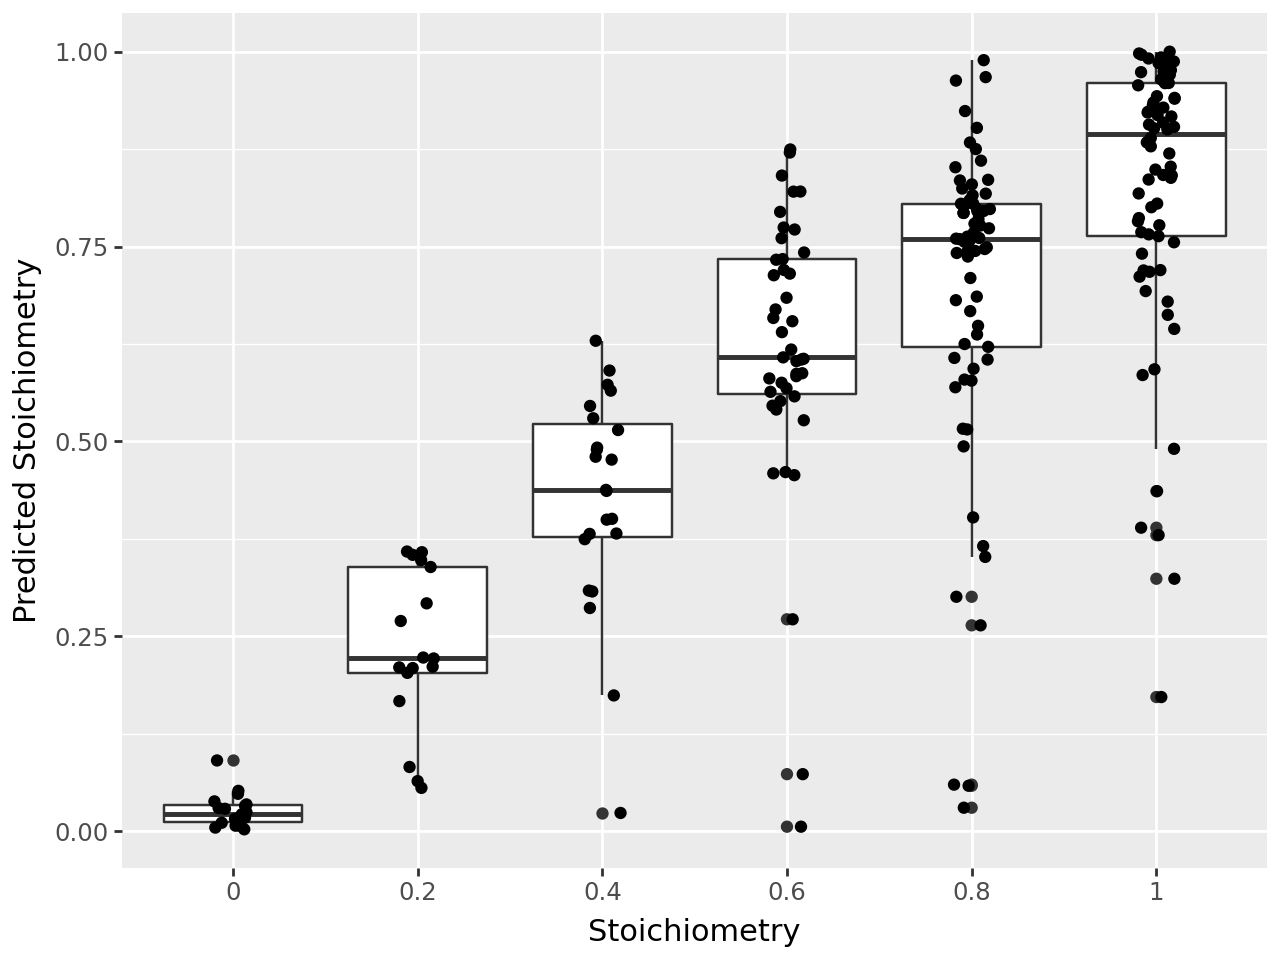

In [66]:
import pandas as pd
from plotnine import *

files=["/root/sunxh/data/m5C/data_stoichiometry/xpore/diffmod/out_0/diffmod.table",
       "/root/sunxh/data/m5C/data_stoichiometry/xpore/diffmod/out_20/diffmod.table",
       "/root/sunxh/data/m5C/data_stoichiometry/xpore/diffmod/out_40/diffmod.table",
       "/root/sunxh/data/m5C/data_stoichiometry/xpore/diffmod/out_60/diffmod.table",
       "/root/sunxh/data/m5C/data_stoichiometry/xpore/diffmod/out_80/diffmod.table",
       "/root/sunxh/data/m5C/data_stoichiometry/xpore/diffmod/out_100/diffmod.table"]

stoi_dict={0:"0",1:"0.2",2:"0.4",3:"0.6",4:"0.8",5:"1"}
X,Y=[],[]
kmer_dict={}
for i,file in enumerate(files):
    with open(file) as f:
        for j,line in enumerate(f):
            line=line.rstrip()
            if "C2" in line:
                kmer=line.split(",")[2]
                pval=float(line.split(",")[4])
                if kmer[2] != "C"  or j%2!=0 :
                    continue
                if kmer not in kmer_dict:
                    kmer_dict[kmer]=[0,0]
                kmer_dict[kmer][1]+=1
                mod_rate=abs(float(line.split(",")[3]))
                X.append(stoi_dict[i])
                Y.append(mod_rate)
                methods.append("xPore")
data=pd.DataFrame({"Stoichiometry":X,"Predicted Stoichiometry":Y})
data.to_csv("/root/sunxh/WaveCrossMamba/data_csv/xpore_stoichiometry_predictions.csv", index=False)

p=(ggplot(data, aes(x='Stoichiometry', y='Predicted Stoichiometry'))
    + geom_boxplot()
    + geom_jitter(width = 0.1)
    + scale_x_discrete()
  )
print(p)
p.show()

In [ ]:
#bash code
#tombo resquiggle

tombo resquiggle --overwrite --basecall-group Basecall_1D_000 \
/root/sunxh/data/m5C/data_stoichiometry1/mod_0_guppy \
/root/sunxh/data/fna/ELIGOS_C1.fa \
--processes 40 --fit-global-scale --include-event-stdev --ignore-read-locks &

tombo resquiggle --overwrite --basecall-group Basecall_1D_000 \
/root/sunxh/data/m5C/data_stoichiometry1/mod_20_guppy \
/root/sunxh/data/fna/ELIGOS_C1.fa \
--processes 40 --fit-global-scale --include-event-stdev --ignore-read-locks &

tombo resquiggle --overwrite --basecall-group Basecall_1D_000 \
/root/sunxh/data/m5C/data_stoichiometry1/mod_40_guppy \
/root/sunxh/data/fna/ELIGOS_C1.fa \
--processes 40 --fit-global-scale --include-event-stdev --ignore-read-locks &

tombo resquiggle --overwrite --basecall-group Basecall_1D_000 \
/root/sunxh/data/m5C/data_stoichiometry1/mod_60_guppy \
/root/sunxh/data/fna/ELIGOS_C1.fa \
--processes 40 --fit-global-scale --include-event-stdev --ignore-read-locks &

tombo resquiggle --overwrite --basecall-group Basecall_1D_000 \
/root/sunxh/data/m5C/data_stoichiometry1/mod_80_guppy \
/root/sunxh/data/fna/ELIGOS_C1.fa \
--processes 40 --fit-global-scale --include-event-stdev --ignore-read-locks &

tombo resquiggle --overwrite --basecall-group Basecall_1D_000 \
/root/sunxh/data/m5C/data_stoichiometry1/mod_100_guppy \
/root/sunxh/data/fna/ELIGOS_C1.fa \
--processes 40 --fit-global-scale --include-event-stdev --ignore-read-locks

In [ ]:
minimap2 -ax map-ont  -t 8 \
/root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/mod_0_guppy/pass/mod_0.fastq | samtools sort \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_0.bam -T m5C.tmp

minimap2 -ax map-ont  -t 8 \
/root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/mod_20_guppy/pass/mod_20.fastq | samtools sort \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_20.bam -T m5C.tmp

minimap2 -ax map-ont  -t 8 \
/root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/mod_40_guppy/pass/mod_40.fastq | samtools sort \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_40.bam -T m5C.tmp

minimap2 -ax map-ont  -t 8 \
/root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/mod_60_guppy/pass/mod_60.fastq | samtools sort \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_60.bam -T m5C.tmp

minimap2 -ax map-ont  -t 8 \
/root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/mod_80_guppy/pass/mod_80.fastq | samtools sort \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_80.bam -T m5C.tmp

minimap2 -ax map-ont  -t 8 \
/root/sunxh/data/fna/ELIGOS_C1.fa \
/root/sunxh/data/m5C/data_stoichiometry1/mod_100_guppy/pass/mod_100.fastq | samtools sort \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_100.bam -T m5C.tmp

samtools view -h -o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_0.sam /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_0.bam
samtools view -h -o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_20.sam /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_20.bam
samtools view -h -o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_40.sam /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_40.bam
samtools view -h -o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_60.sam /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_60.bam
samtools view -h -o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_80.sam /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_80.bam
samtools view -h -o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_100.sam /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_100.bam



In [ ]:
python /root/sunxh/WaveCrossMamba/utils/raw_fast5_current_signal.py --p 10 \
--fast5 /root/sunxh/data/m5C/data_stoichiometry1/mod_0_guppy/workspace \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_0.tsv --clip=10 \
-r /root/sunxh/data/fna/ELIGOS_C1.fa \
--sam /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_0.sam

python /root/sunxh/WaveCrossMamba/utils/raw_fast5_current_signal.py --p 10 \
--fast5 /root/sunxh/data/m5C/data_stoichiometry1/mod_20_guppy/workspace  \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_20.tsv --clip=10 \
-r /root/sunxh/data/fna/ELIGOS_C1.fa \
--sam /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_20.sam

python /root/sunxh/WaveCrossMamba/utils/raw_fast5_current_signal.py --p 10 \
--fast5 /root/sunxh/data/m5C/data_stoichiometry1/mod_40_guppy/workspace  \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_40.tsv --clip=10 \
-r /root/sunxh/data/fna/ELIGOS_C1.fa \
--sam /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_40.sam

python /root/sunxh/WaveCrossMamba/utils/raw_fast5_current_signal.py --p 10 \
--fast5 /root/sunxh/data/m5C/data_stoichiometry1/mod_60_guppy/workspace  \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_60.tsv --clip=10 \
-r /root/sunxh/data/fna/ELIGOS_C1.fa \
--sam /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_60.sam

python /root/sunxh/WaveCrossMamba/utils/raw_fast5_current_signal.py --p 10 \
--fast5 /root/sunxh/data/m5C/data_stoichiometry1/mod_80_guppy/workspace  \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_80.tsv --clip=10 \
-r /root/sunxh/data/fna/ELIGOS_C1.fa \
--sam /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_80.sam

python /root/sunxh/WaveCrossMamba/utils/raw_fast5_current_signal.py --p 10 \
--fast5 /root/sunxh/data/m5C/data_stoichiometry1/mod_100_guppy/workspace  \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_100.tsv --clip=10 \
-r /root/sunxh/data/fna/ELIGOS_C1.fa \
--sam /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_100.sam

In [ ]:
python /root/sunxh/WaveCrossMamba/utils/signal_features.py \
--signal_file /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_0.tsv \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_0.feature.tsv --motif NNCNN

python /root/sunxh/WaveCrossMamba/utils/signal_features.py \
--signal_file /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_20.tsv \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_20.feature.tsv --motif NNCNN

python /root/sunxh/WaveCrossMamba/utils/signal_features.py \
--signal_file /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_40.tsv \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_40.feature.tsv --motif NNCNN

python /root/sunxh/WaveCrossMamba/utils/signal_features.py \
--signal_file /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_60.tsv \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_60.feature.tsv --motif NNCNN

python /root/sunxh/WaveCrossMamba/utils/signal_features.py \
--signal_file /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_80.tsv \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_80.feature.tsv --motif NNCNN

python /root/sunxh/WaveCrossMamba/utils/signal_features.py \
--signal_file /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_100.tsv \
-o /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_100.feature.tsv --motif NNCNN

In [ ]:


python /root/sunxh/TandemMod-master/scripts/TandemMod.py --run_mode predict --feature_file /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_0.feature.tsv --predict_result /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_0.result
python /root/sunxh/TandemMod-master/scripts/TandemMod.py --run_mode predict --feature_file /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_20.feature.tsv --predict_result /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_20.result
python /root/sunxh/TandemMod-master/scripts/TandemMod.py --run_mode predict --feature_file /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_40.feature.tsv --predict_result /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_40.result
python /root/sunxh/TandemMod-master/scripts/TandemMod.py --run_mode predict --feature_file /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_60.feature.tsv --predict_result /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_60.result
python /root/sunxh/TandemMod-master/scripts/TandemMod.py --run_mode predict --feature_file /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_80.feature.tsv --predict_result /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_80.result
python /root/sunxh/TandemMod-master/scripts/TandemMod.py --run_mode predict --feature_file /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_100.feature.tsv --predict_result /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_100.result


<ggplot: (640 x 480)>


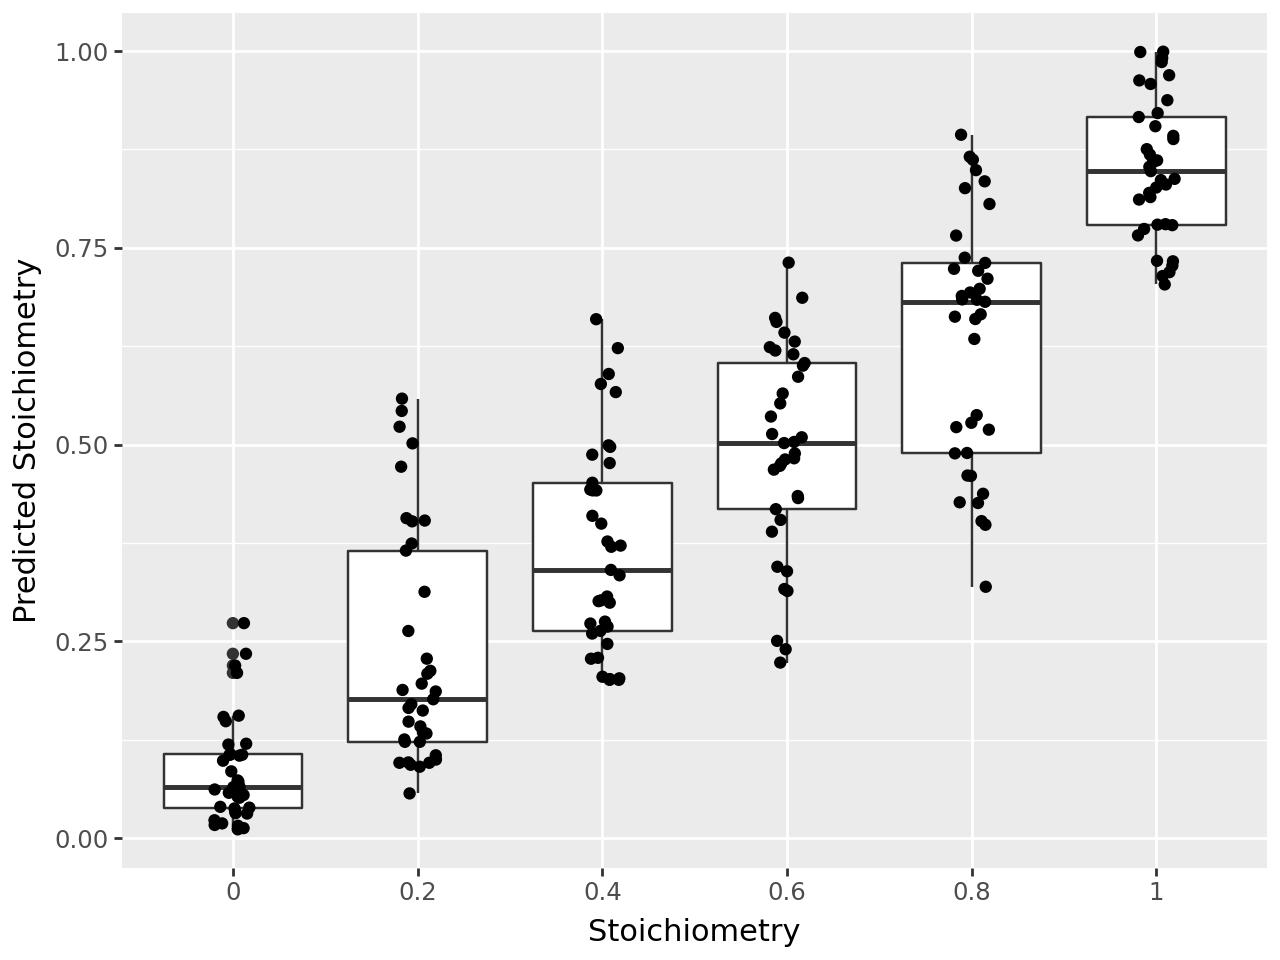

In [ ]:
#attention plot
import pandas as pd
methods=[]
from plotnine import *
files=["/root/sunxh/data/m5C/data_stoichiometry1/attention/mod_0.result",
       "/root/sunxh/data/m5C/data_stoichiometry1/attention/mod_20.result",
       "/root/sunxh/data/m5C/data_stoichiometry1/attention/mod_40.result",
       "/root/sunxh/data/m5C/data_stoichiometry1/attention/mod_60.result",
       "/root/sunxh/data/m5C/data_stoichiometry1/attention/mod_80.result",
       "/root/sunxh/data/m5C/data_stoichiometry1/attention/mod_100.result"]
stoi_dict={0:"0",1:"0.2",2:"0.4",3:"0.6",4:"0.8",5:"1"}
X,Y=[],[]
for i,file in enumerate(files):
    mod_rate_dict={}
    with open(file) as f:
        for j,line in enumerate(f):
            line=line.rstrip()
            id=line.split("\t")[1]
            if id not in mod_rate_dict:
                mod_rate_dict[id]=[0,0]
            if line.split("\t")[4]=="mod":
                mod_rate_dict[id][0]+=1
            mod_rate_dict[id][1]+=1
    for k,id in enumerate(mod_rate_dict):
        if mod_rate_dict[id][1] < 20:
            continue
        xx = mod_rate_dict[id][0]/mod_rate_dict[id][1]
        if k%2 ==0:
            X.append(stoi_dict[i])
            Y.append(xx)
            methods.append("TandemMod")
data=pd.DataFrame({"Stoichiometry":X,"Predicted Stoichiometry":Y})
data.to_csv("/root/sunxh/WaveCrossMamba/data_csv/tandemmod_stoichiometry_predictions.csv", index=False)
p=(ggplot(data, aes(x='Stoichiometry', y='Predicted Stoichiometry'))
    + geom_boxplot()
    + geom_jitter(width = 0.1)
    + scale_x_discrete()
  )
print(p)
p.show()


In [ ]:
python /root/sunxh/WaveCrossMamba/train_test/predict_site.py --input /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_0.feature.tsv --modified m5c --o /root/sunxh/WaveCrossMamba/result_reproduce/mod_0.result
python /root/sunxh/WaveCrossMamba/train_test/predict_site.py --input /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_20.feature.tsv --modified m5c --o /root/sunxh/WaveCrossMamba/result_reproduce/mod_20.result
python /root/sunxh/WaveCrossMamba/train_test/predict_site.py --input /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_40.feature.tsv --modified m5c --o /root/sunxh/WaveCrossMamba/result_reproduce/mod_40.result
python /root/sunxh/WaveCrossMamba/train_test/predict_site.py --input /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_60.feature.tsv --modified m5c --o /root/sunxh/WaveCrossMamba/result_reproduce/mod_60.result
python /root/sunxh/WaveCrossMamba/train_test/predict_site.py --input /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_80.feature.tsv --modified m5c --o /root/sunxh/WaveCrossMamba/result_reproduce/mod_80.result
python /root/sunxh/WaveCrossMamba/train_test/predict_site.py --input /root/sunxh/data/m5C/data_stoichiometry1/attention/mod_100.feature.tsv --modified m5c --o /root/sunxh/WaveCrossMamba/result_reproduce/mod_100.result



<ggplot: (640 x 480)>


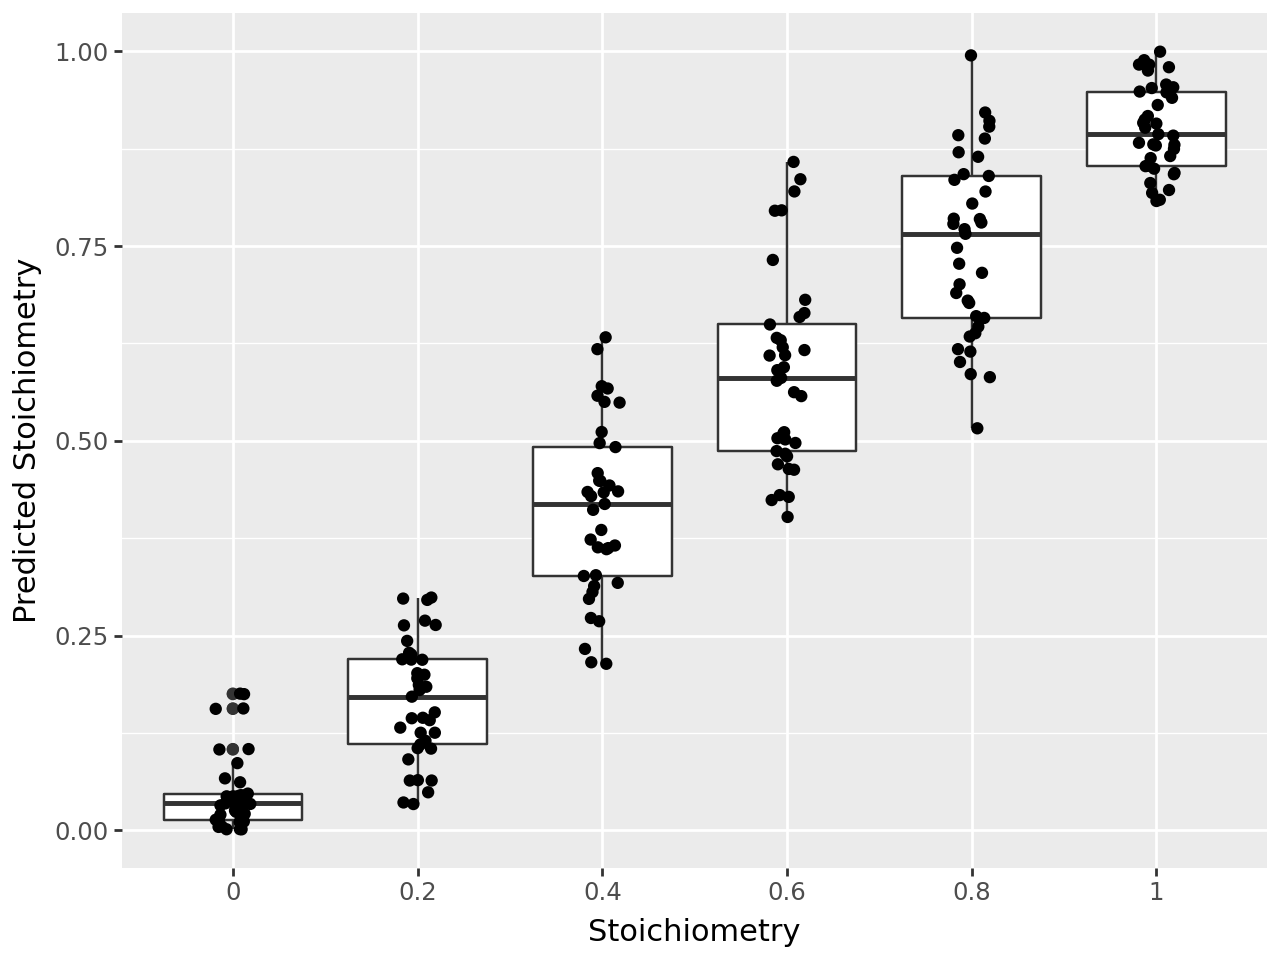

In [ ]:
#attention plot
import pandas as pd
from plotnine import *
files=["/root/sunxh/WaveCrossMamba/result_reproduce/mod_0.result",
       "/root/sunxh/WaveCrossMamba/result_reproduce/mod_20.result",
       "/root/sunxh/WaveCrossMamba/result_reproduce/mod_40.result",
       "/root/sunxh/WaveCrossMamba/result_reproduce/mod_60.result",
       "/root/sunxh/WaveCrossMamba/result_reproduce/mod_80.result",
       "/root/sunxh/WaveCrossMamba/result_reproduce/mod_100.result"]
stoi_dict={0:"0",1:"0.2",2:"0.4",3:"0.6",4:"0.8",5:"1"}
X,Y=[],[]
for i,file in enumerate(files):
    mod_rate_dict={}
    with open(file) as f:
        for j,line in enumerate(f):
            line=line.rstrip()
            id="_".join([line.split("\t")[0],line.split("\t")[1]])
            if id not in mod_rate_dict:
                mod_rate_dict[id]=[0,0]
            if line.split("\t")[4]=="m5C":
                mod_rate_dict[id][0]+=1
            mod_rate_dict[id][1]+=1
    for k,id in enumerate(mod_rate_dict):
        if mod_rate_dict[id][1]<20:
            continue
        if k%2==0:
            xx = mod_rate_dict[id][0]/mod_rate_dict[id][1]
            X.append(stoi_dict[i])
            Y.append(xx)
        methods.append("WattMamba")
data=pd.DataFrame({"Stoichiometry":X,"Predicted Stoichiometry":Y})
data.to_csv("/root/sunxh/WaveCrossMamba/data_csv/wattmamba_stoichiometry_predictions.csv", index=False)
p=(ggplot(data, aes(x='Stoichiometry', y='Predicted Stoichiometry'))
    + geom_boxplot()
    + geom_jitter(width = 0.1)
    + scale_x_discrete()
  )
print(p)
p.show()